# Model Evaluation

## Objective

This notebook evaluates the trained machine learning models developed for PCOS prediction. The aim is to compare model performance using accuracy, precision, recall, F1-score, confusion matrices, and ROC curves. This helps identify which model provides the best balance between predictive performance, clinical usefulness, and interpretability.

In [1]:

# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [2]:

# Load and Prepare Dataset

# Load cleaned dataset
df = pd.read_csv("../data/processed/pcos_cleaned.csv")

# Separate features and target variable
X = df.drop(columns=["PCOS (Y/N)"])
y = df["PCOS (Y/N)"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert object columns to numeric
X_train["II    beta-HCG(mIU/mL)"] = pd.to_numeric(X_train["II    beta-HCG(mIU/mL)"], errors="coerce")
X_test["II    beta-HCG(mIU/mL)"] = pd.to_numeric(X_test["II    beta-HCG(mIU/mL)"], errors="coerce")

X_train["AMH(ng/mL)"] = pd.to_numeric(X_train["AMH(ng/mL)"], errors="coerce")
X_test["AMH(ng/mL)"] = pd.to_numeric(X_test["AMH(ng/mL)"], errors="coerce")

# Handle remaining missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset loaded and prepared for evaluation.")

Dataset loaded and prepared for evaluation.


In [3]:

# Recreate Trained Models

# Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# SVM
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("All models recreated successfully for evaluation.")

All models recreated successfully for evaluation.


# Model Performance Comparison

This section compares the performance of all machine learning models using standard classification metrics.

The evaluation focuses on:

- Accuracy
- Precision
- Recall
- F1-score

These metrics are particularly important in healthcare prediction because false negatives and false positives can significantly affect clinical decision-making.

In [4]:
# Create Model Comparison Table

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1-Score": round(f1 * 100, 2)
    })

# Convert to dataframe
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,88.07,81.08,83.33,82.19
1,Decision Tree,88.99,85.29,80.56,82.86
2,Random Forest,92.66,96.67,80.56,87.88
3,SVM,89.91,93.10,75.00,83.08
4,XGBoost,91.74,93.55,80.56,86.57


# Confusion Matrix Analysis

Confusion matrices show how well each model classified PCOS and non-PCOS cases.

They help identify:
- True Positives
- True Negatives
- False Positives
- False Negatives

This is important in healthcare because missed diagnoses (false negatives) can affect early treatment.

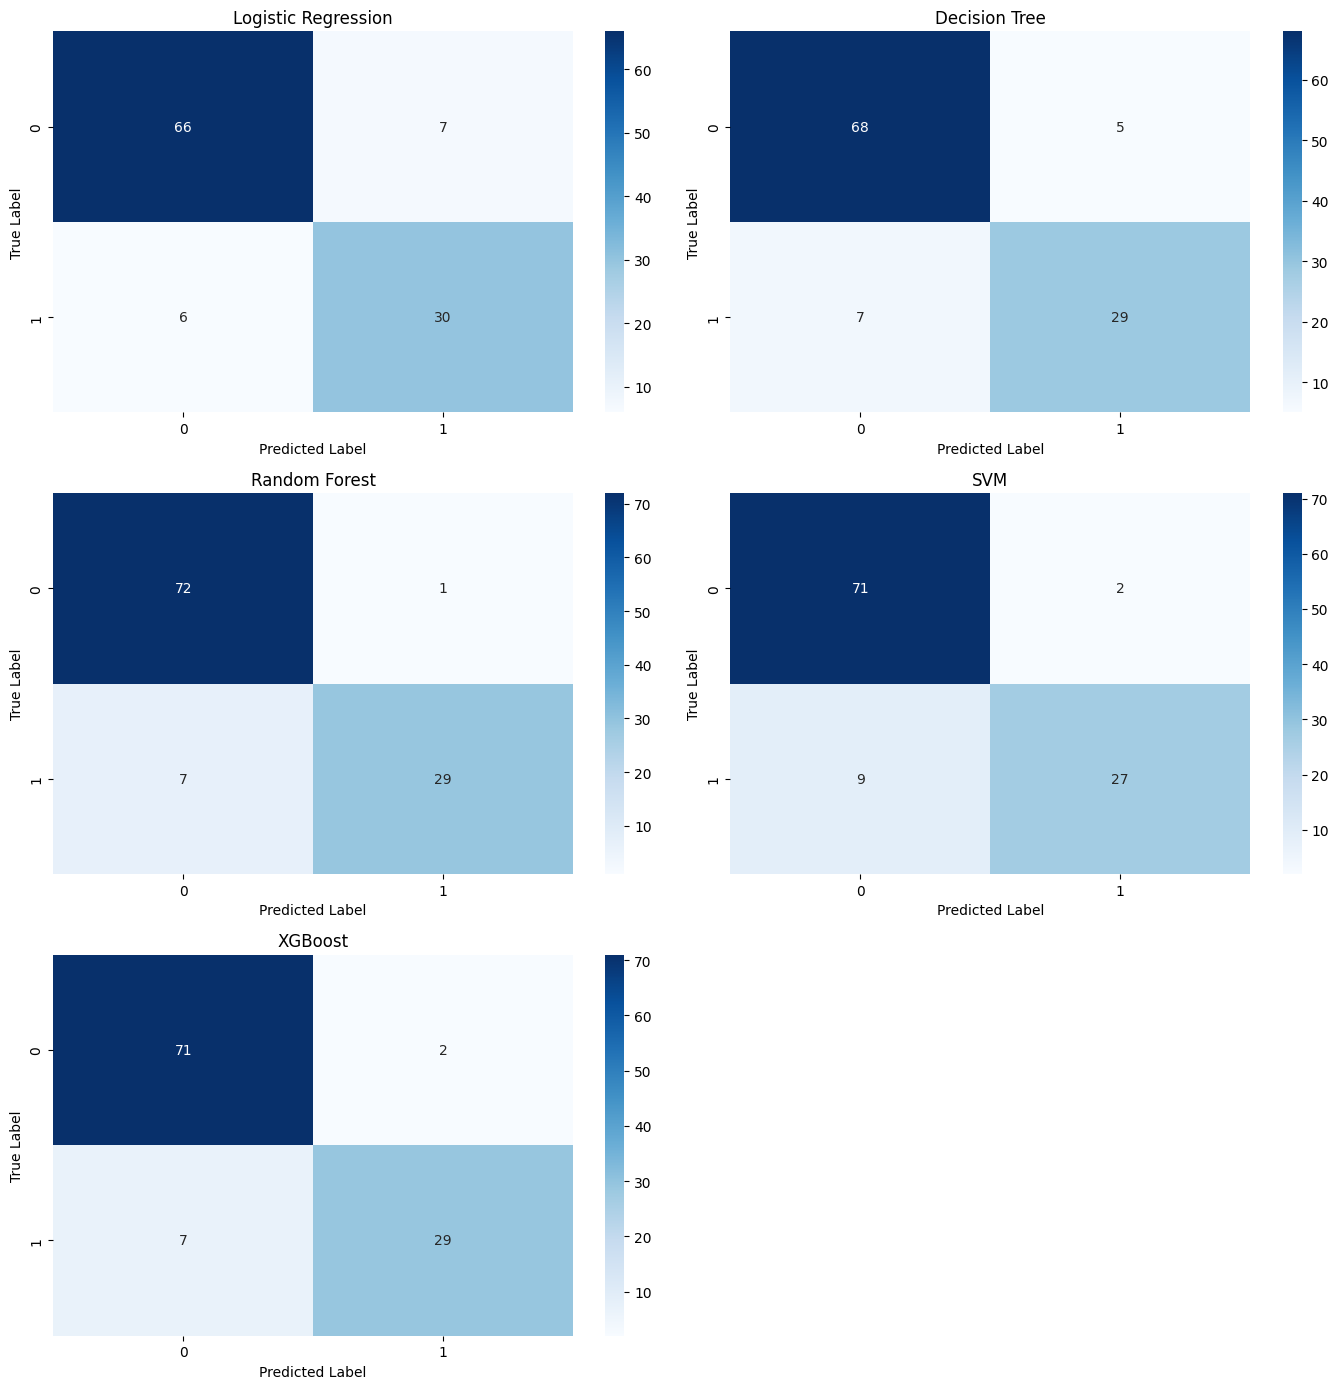

In [6]:
# Plot confusion matrices for all models

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Store model predictions
model_predictions = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
    
}

# Generate confusion matrix for each model
for ax, (model_name, predictions) in zip(axes.flatten(), model_predictions.items()):

    # Create confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Plot heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    # Add labels and titles
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")


# Remove unused subplot
fig.delaxes(axes[2, 1])

# Adjust layout
plt.tight_layout()
plt.show()

# ROC Curve Analysis

ROC curves were used to compare the classification performance of each model.

The Area Under the Curve (AUC) helps measure how effectively a model can distinguish between PCOS and non-PCOS cases.

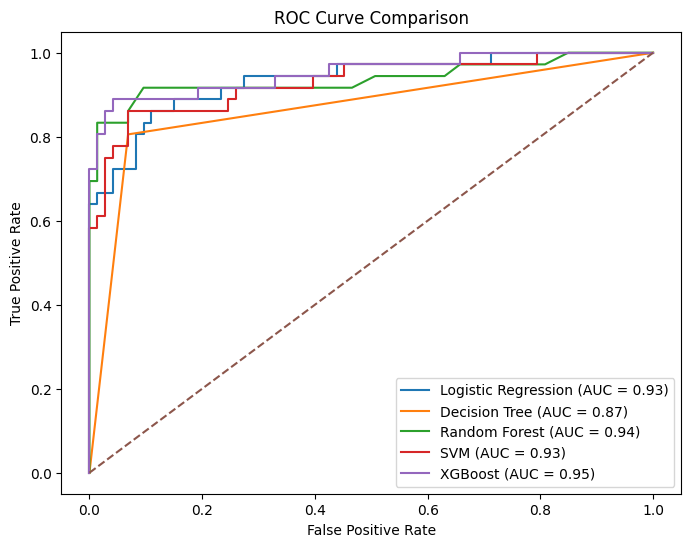

In [7]:
# Generate prediction probabilities

log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve values
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# Calculate AUC scores
log_auc = roc_auc_score(y_test, log_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
svm_auc = roc_auc_score(y_test, svm_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.2f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")

# Random prediction line
plt.plot([0, 1], [0, 1], linestyle="--")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [8]:
# Create AUC comparison table

auc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    "AUC Score": [
        round(log_auc, 2),
        round(dt_auc, 2),
        round(rf_auc, 2),
        round(svm_auc, 2),
        round(xgb_auc, 2)
    ]
})

auc_results

,Model,AUC Score
0,Logistic Regression,0.93
1,Decision Tree,0.87
2,Random Forest,0.94
3,SVM,0.93
4,XGBoost,0.95
